In [1]:
# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

print("Setup complete.")

Setup complete.


In [9]:
import os

BASE_PATH = "/kaggle/input/datasets/redwankarimsony/heart-disease-data"

print(os.listdir(BASE_PATH))

['heart_disease_uci.csv']


In [10]:
import pandas as pd

DATA_PATH = BASE_PATH + "/heart_disease_uci.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (920, 16)
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4          

In [11]:
import glob
import pandas as pd

csv_files = glob.glob(
    "/kaggle/input/datasets/redwankarimsony/heart-disease-data/**/*.csv",
    recursive=True
)

print("CSV files found:")
for file in csv_files:
    print(file)

DATA_PATH = csv_files[0]

df = pd.read_csv(DATA_PATH)

print("\nDataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

CSV files found:
/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv

Dataset shape: (920, 16)

First 5 rows:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [12]:
# 3. Dataset information
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate rows:", df.duplicated().sum())

Columns:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Data types:
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

Missing values:


,Missing Values
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55



Duplicate rows: 0


Original target distribution:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


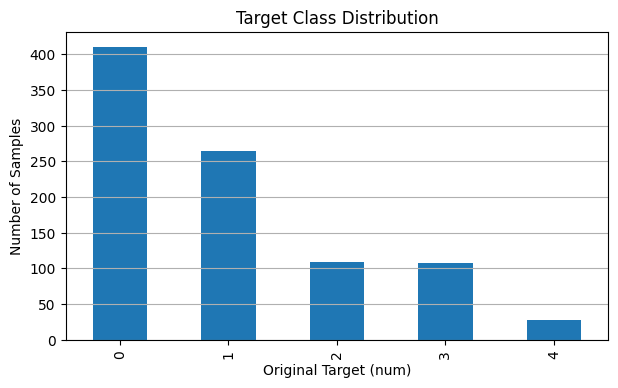

In [13]:
# 4. Target distribution
print("Original target distribution:")
print(df["num"].value_counts().sort_index())

plt.figure(figsize=(7, 4))
df["num"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Original Target (num)")
plt.ylabel("Number of Samples")
plt.title("Target Class Distribution")
plt.grid(axis="y")
plt.show()


Binary target distribution:
target
0    411
1    509
Name: count, dtype: int64


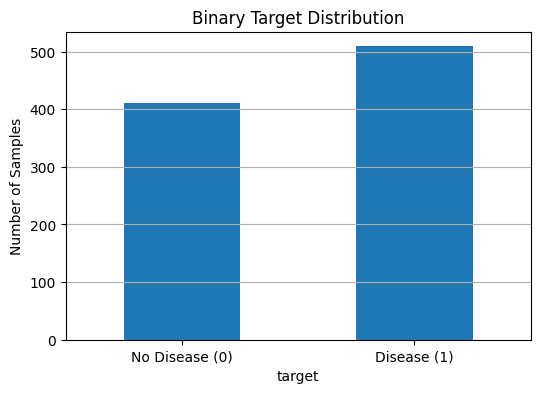

In [14]:
# 5. Convert target into binary classification
df["target"] = (df["num"] > 0).astype(int)

print("Binary target distribution:")
print(df["target"].value_counts().sort_index())

plt.figure(figsize=(6, 4))
df["target"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["No Disease (0)", "Disease (1)"], rotation=0)
plt.ylabel("Number of Samples")
plt.title("Binary Target Distribution")
plt.grid(axis="y")
plt.show()

In [15]:
# 6. Prepare X and y
# Drop original target and identifier column if present.
drop_cols = ["num", "target"]

if "id" in df.columns:
    drop_cols.append("id")

X = df.drop(columns=drop_cols)
y = df["target"]

print("Feature shape:", X.shape)
print("Target shape :", y.shape)

Feature shape: (920, 14)
Target shape : (920,)


In [16]:
# 7. Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numerical features:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

Categorical features:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [17]:
# 8. Preprocessing
# Numerical: fill missing values + standardize
# Categorical: fill missing values + one-hot encode

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [18]:
# 9. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 736
Testing samples : 184


In [19]:
# 10. Decision Tree
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="entropy",
        max_depth=5,
        random_state=42
    ))
])

dt_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [20]:
# 11. KNN
knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

print("KNN trained successfully!")
print("K =", knn_model.named_steps["classifier"].n_neighbors)

KNN trained successfully!
K = 5


In [21]:
# 12. Gaussian Naive Bayes
nb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GaussianNB())
])

nb_model.fit(X_train, y_train)

print("Gaussian Naive Bayes trained successfully!")

Gaussian Naive Bayes trained successfully!


In [22]:
# 13. SVM
svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

print("SVM trained successfully!")
print("Kernel = RBF")


SVM trained successfully!
Kernel = RBF


In [23]:
# 14. Generate predictions for all models
models = {
    "Decision Tree": dt_model,
    "KNN": knn_model,
    "Naive Bayes": nb_model,
    "SVM": svm_model
}

predictions = {}
probabilities = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]

print("Predictions generated for all four models.")

Predictions generated for all four models.


In [24]:
# 15. Accuracy
for name in models:
    acc = accuracy_score(y_test, predictions[name])
    print(f"{name} Accuracy : {acc:.4f}")


Decision Tree Accuracy : 0.7880
KNN Accuracy : 0.8370
Naive Bayes Accuracy : 0.8696
SVM Accuracy : 0.8641


In [25]:
# 16. Complete evaluation metrics
results = []

for name in models:
    y_pred = predictions[name]
    y_prob = probabilities[name]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(
    by="Accuracy", ascending=False
).reset_index(drop=True)

display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}))

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Naive Bayes,0.8696,0.8750,0.8922,0.8835,0.9174
1,SVM,0.8641,0.8348,0.9412,0.8848,0.9218
2,KNN,0.8370,0.8273,0.8922,0.8585,0.8887
3,Decision Tree,0.7880,0.8000,0.8235,0.8116,0.8410


In [26]:
# 17. Classification report for every model
for name in models:
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(
        y_test,
        predictions[name],
        target_names=["No Disease", "Disease"],
        digits=4,
        zero_division=0
    ))

Decision Tree
              precision    recall  f1-score   support

  No Disease     0.7722    0.7439    0.7578        82
     Disease     0.8000    0.8235    0.8116       102

    accuracy                         0.7880       184
   macro avg     0.7861    0.7837    0.7847       184
weighted avg     0.7876    0.7880    0.7876       184

KNN
              precision    recall  f1-score   support

  No Disease     0.8514    0.7683    0.8077        82
     Disease     0.8273    0.8922    0.8585       102

    accuracy                         0.8370       184
   macro avg     0.8393    0.8302    0.8331       184
weighted avg     0.8380    0.8370    0.8359       184

Naive Bayes
              precision    recall  f1-score   support

  No Disease     0.8625    0.8415    0.8519        82
     Disease     0.8750    0.8922    0.8835       102

    accuracy                         0.8696       184
   macro avg     0.8688    0.8668    0.8677       184
weighted avg     0.8694    0.8696    0.8694 

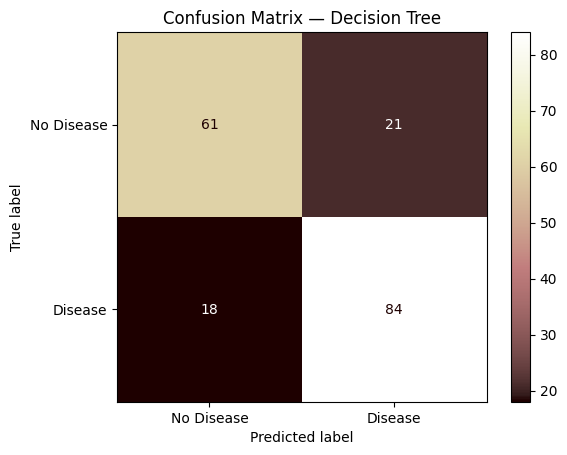

In [28]:
# 18. Confusion Matrix — Decision Tree
cm = confusion_matrix(y_test, predictions["Decision Tree"])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)
disp.plot(values_format="d", cmap="pink")
plt.title("Confusion Matrix — Decision Tree")
plt.grid(False)
plt.show()


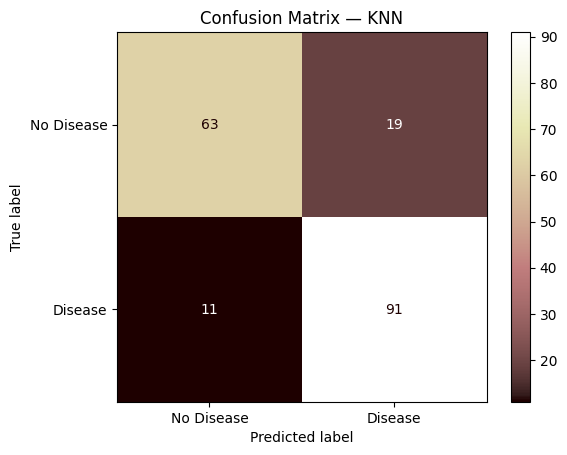

In [30]:
# 19. Confusion Matrix — KNN
cm = confusion_matrix(y_test, predictions["KNN"])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)
disp.plot(values_format="d", cmap="pink")
plt.title("Confusion Matrix — KNN")
plt.grid(False)
plt.show()

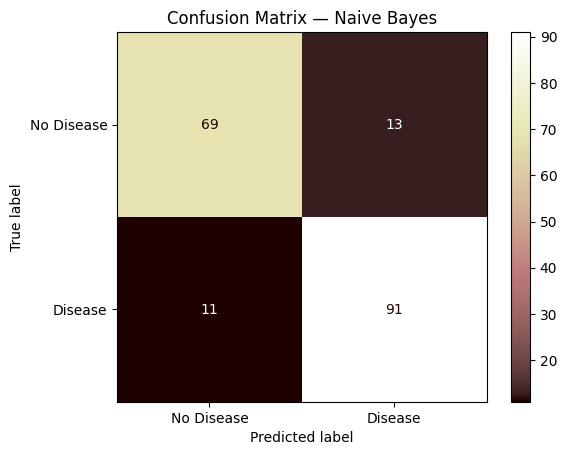

In [31]:
# 20. Confusion Matrix — Naive Bayes
cm = confusion_matrix(y_test, predictions["Naive Bayes"])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)
disp.plot(values_format="d", cmap="pink")
plt.title("Confusion Matrix — Naive Bayes")
plt.grid(False)
plt.show()

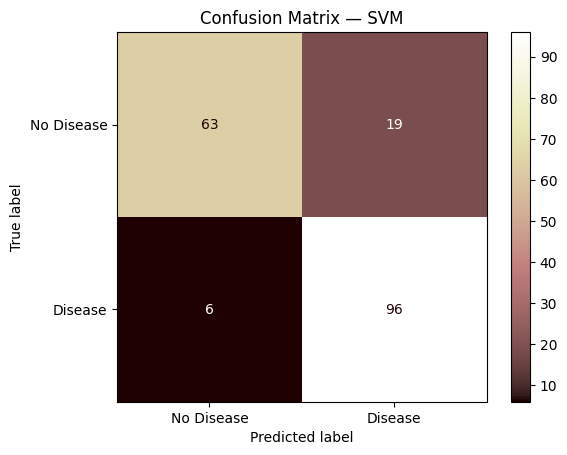

In [33]:
# 21. Confusion Matrix — SVM
cm = confusion_matrix(y_test, predictions["SVM"])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)
disp.plot(values_format="d", cmap="pink")
plt.title("Confusion Matrix — SVM")
plt.grid(False)
plt.show()


<Figure size 900x700 with 0 Axes>

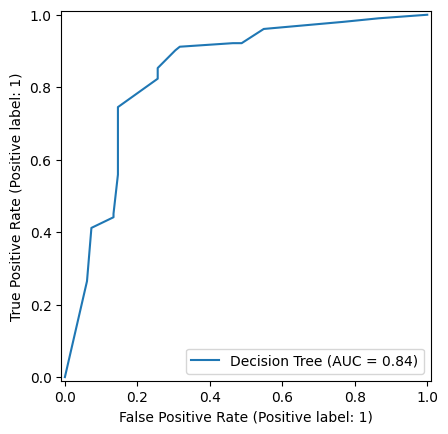

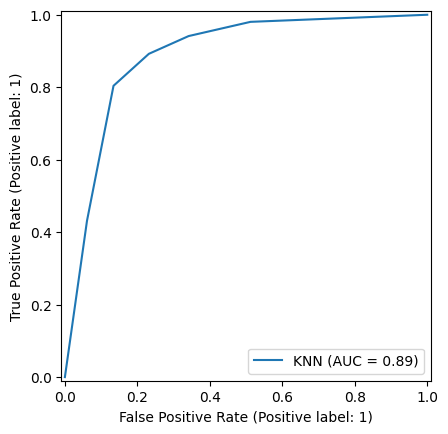

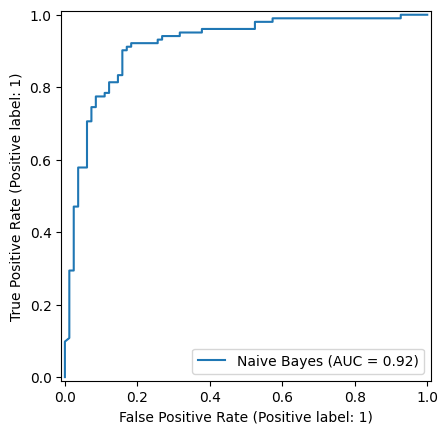

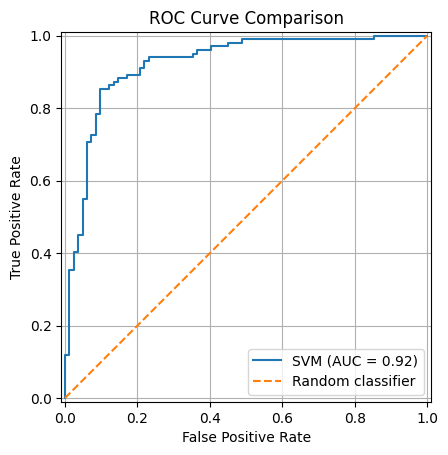

In [34]:
# 22. Combined ROC Curve
plt.figure(figsize=(9, 7))

for name in models:
    RocCurveDisplay.from_predictions(
        y_test,
        probabilities[name],
        name=name
    )

plt.plot([0, 1], [0, 1], "--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.grid(True)
plt.legend()
plt.show()


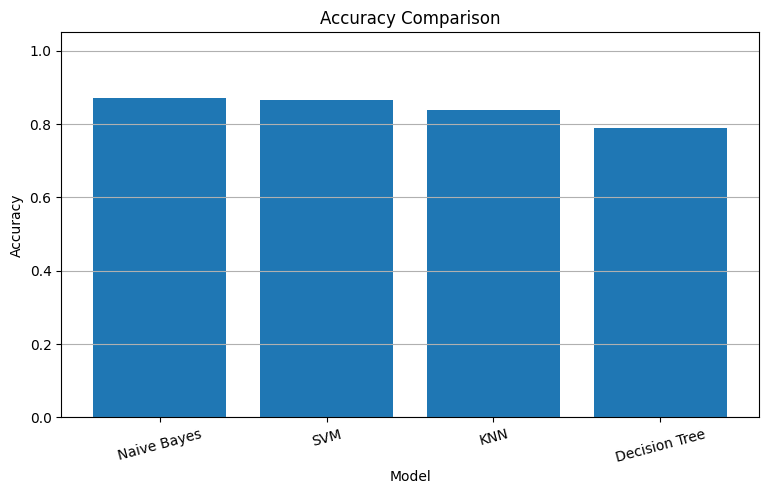

In [35]:
# 23. Accuracy comparison graph
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.ylim(0, 1.05)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.show()

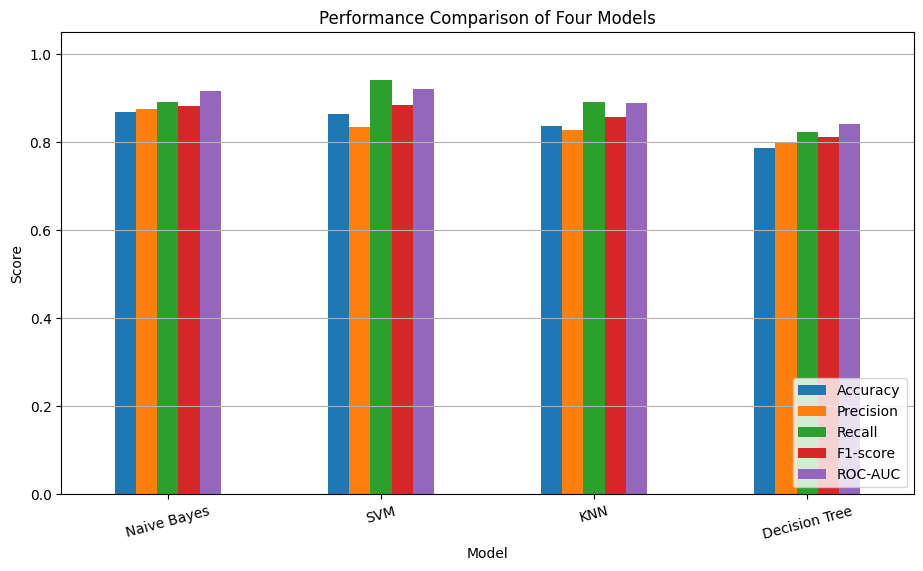

In [36]:
# 24. Compare all evaluation metrics
metric_columns = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

plot_df = results_df.set_index("Model")[metric_columns]

plot_df.plot(kind="bar", figsize=(11, 6))
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Performance Comparison of Four Models")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.legend(loc="lower right")
plt.show()


In [37]:
# 25. Best model
best_accuracy_row = results_df.loc[results_df["Accuracy"].idxmax()]
best_auc_row = results_df.loc[results_df["ROC-AUC"].idxmax()]

print("Best Model by Accuracy :", best_accuracy_row["Model"])
print("Best Accuracy          :", f'{best_accuracy_row["Accuracy"]:.4f}')

print("\nBest Model by ROC-AUC  :", best_auc_row["Model"])
print("Best ROC-AUC            :", f'{best_auc_row["ROC-AUC"]:.4f}')

Best Model by Accuracy : Naive Bayes
Best Accuracy          : 0.8696

Best Model by ROC-AUC  : SVM
Best ROC-AUC            : 0.9218


In [38]:
# 26. Save final results
results_df.to_csv("uci_heart_disease_model_comparison.csv", index=False)
results_df.to_excel("uci_heart_disease_model_comparison.xlsx", index=False)

print("Results saved successfully!")
print("uci_heart_disease_model_comparison.csv")
print("uci_heart_disease_model_comparison.xlsx")


Results saved successfully!
uci_heart_disease_model_comparison.csv
uci_heart_disease_model_comparison.xlsx
